<a href="https://colab.research.google.com/github/formylearningservice-eng/Mathematical-Model/blob/main/physical_chemistry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

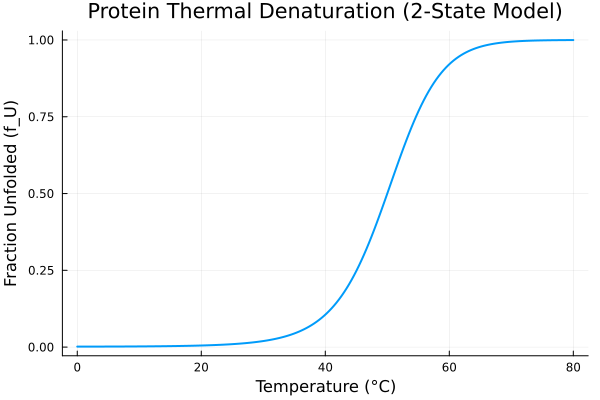

In [ ]:
# タンパク質の熱変性モデル
using Plots

# 1. 物理定数・パラメータの設定
const R = 8.314  # 気体定数 J/(mol·K)
T_m = 323.15     # 融解温度 50 °C (K表記)
ΔH_m = 200.0e3   # 融解エンタルピー J/mol (200 kJ/mol)
ΔCp = 4.0e3      # 熱容量変化 J/(mol·K) (4 kJ/mol·K)

# 2. ギブズ自由エネルギー ΔG(T) の計算関数
# Gibbs-Helmholtz の式
function delta_G(T)
    return ΔH_m * (1 - T / T_m) - ΔCp * ((T_m - T) + T * log(T / T_m))
end

# 3. 変性率 f_U(T) の計算関数
function fraction_unfolded(T)
    ΔG = delta_G(T)
    K = exp(-ΔG / (R * T)) # 平衡定数 K = [U]/[F]
    return K / (1 + K)     # 変性割合 f_U = K / (1 + K)
end

# 4. 温度範囲の設定と計算 (0 °C 〜 80 °C)
temperatures_C = range(0, 80, length=200)
temperatures_K = temperatures_C .+ 273.15
f_U_values = fraction_unfolded.(temperatures_K) # ドット演算子で要素ごとの適用

# 5. 可視化
plot(temperatures_C, f_U_values,
     xlabel = "Temperature (°C)",
     ylabel = "Fraction Unfolded (f_U)",
     title = "Protein Thermal Denaturation (2-State Model)",
     legend = false,
     linewidth = 2)

In [ ]:
# 初回実行時のみパッケージをインストール（Colabセルで実行）
import Pkg; Pkg.add("DifferentialEquations"); Pkg.add("Plots")

using DifferentialEquations
using Plots

# 1. 微分方程式系（反応速度式）の定義
function consecutive_reaction!(du, u, p, t)
    A, B, C = u
    k1, k2 = p

    du[1] = -k1 * A          # d[A]/dt
    du[2] =  k1 * A - k2 * B # d[B]/dt
    du[3] =  k2 * B          # d[C]/dt
end

# 2. 初期値とパラメータ設定
u0 = [1.0, 0.0, 0.0]  # 初期濃度 [A]=1.0, [B]=0.0, [C]=0.0 (M)
p = [0.5, 0.1]        # 速度定数 k1 = 0.5, k2 = 0.1 (1/s)
tspan = (0.0, 30.0)   # 時間範囲 0 ～ 30 秒

# 3. ODE問題の設定と数値解法
problem = ODEProblem(consecutive_reaction!, u0, tspan, p)
solution = solve(problem, Tsit5()) # Tsit5 は標準的・高速なアルゴリズム

# 4. 可視化
plot(solution,
     label=["[A] (Reactant)" "[B] (Intermediate)" "[C] (Product)"],
     xlabel="Time (s)",
     ylabel="Concentration (M)",
     title="Consecutive First-Order Reaction (A -> B -> C)",
     linewidth=2)

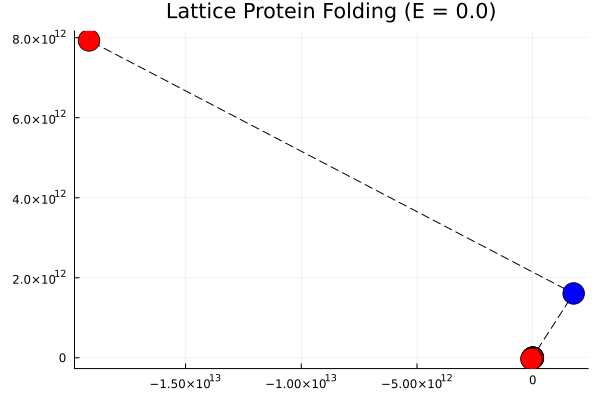

In [ ]:
using Plots

# 1. 配列とパラメータ設定
# 1: Hydrophobic (H), 0: Polar (P)
const sequence = [1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1]
const N = length(sequence)
const ε = -1.0  # H-H 接触エネルギー (J または arbitrary unit)
const T = 0.5   # 無次元温度 (低いほど安定構造へ収束しやすい)

# 2. 初期構造（横一列に配置）
# 座標の配列 [ (x1, y1), (x2, y2), ... ]
coords = [(i, 0) for i in 1:N]

# 3. エネルギー計算関数 (配列接続されていない隣接 H-H の数をカウント)
function calculate_energy(coords, seq)
    E = 0.0
    for i in 1:N
        for j in (i + 2):N  # ペプチド結合で隣接しているペアは除く
            if seq[i] == 1 && seq[j] == 1
                # マンハッタン距離が 1 (格子上で上下左右に隣接)
                dist = abs(coords[i][1] - coords[j][1]) + abs(coords[i][2] - coords[j][2])
                if dist == 1
                    E += ε
                end
            end
        end
    end
    return E
end

# 4. モンテカルロ・シミュレーション (メトロポリス法)
steps = 20000
current_E = calculate_energy(coords, sequence)

for step in 1:steps
    # ランダムに1つのアミノ酸を選んで回転試行 (端以外のピボット移動)
    idx = rand(2:N)
    old_coord = coords[idx]

    # 90度回転の移動候補
    prev_x, prev_y = coords[idx-1]
    dx, dy = old_coord[1] - prev_x, old_coord[2] - prev_y
    # (dx, dy) を ±90度回転
    new_dx, new_dy = rand([(-dy, dx), (dy, -dx)])
    new_coord = (prev_x + new_dx, prev_y + new_dy)

    # 重なりチェック (Self-Avoiding Walk)
    if !(new_coord in coords)
        # 一時的に更新
        coords_trial = copy(coords)
        coords_trial[idx] = new_coord

        new_E = calculate_energy(coords_trial, sequence)
        ΔE = new_E - current_E

        # メトロポリス判定 (エネルギー低下、または確率的な受容)
        if ΔE < 0 || rand() < exp(-ΔE / T)
            coords[idx] = new_coord
            current_E = new_E
        end
    end
end

# 5. 可視化
xs = [c[1] for c in coords]
ys = [c[2] for c in coords]
colors = [sequence[i] == 1 ? :red : :blue for i in 1:N]

plot(xs, ys, seriestype = :path, linecolor = :black, linestyle = :dash, legend = false, title = "Lattice Protein Folding (E = $current_E)")
scatter!(xs, ys, color = colors, markersize = 12)

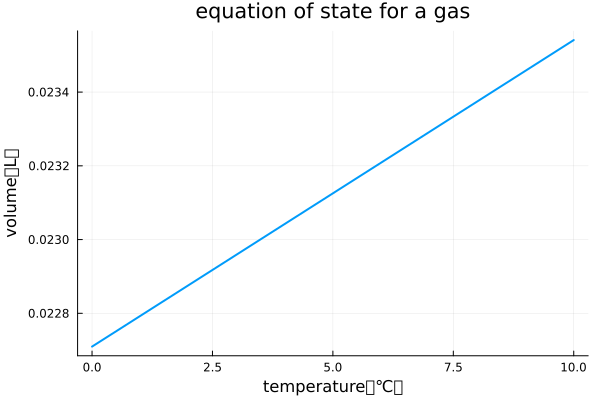

GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current font: 65288
GKS: glyph missing from current font: 65289
GKS: glyph missing from current 

In [ ]:
# 理想気体の状態方程式モデル(PV = nRT) : 温度による体積変化
using Plots

# 1. 物理定数・パラメータの設定
const R = 8.314  # 気体定数 J/(mol·K)
      P = 1.00 * 10^5  # 標準の気圧 Pa
      # t = c + 273.15   絶対温度 K
      n = 1  # 物質量 mol
      v = 1  # 気体体積 L

function f(c)
    return n * R * (c + 273.15) / P
end

c = range(0, 10, length=100)
volume = f.(c)

# 5. 可視化
plot(c, volume,
    xlabel = "temperature（℃）",
    ylabel = "volume（L）",
    title = "equation of state for a gas",
    legend = false,
    linewidth = 2)

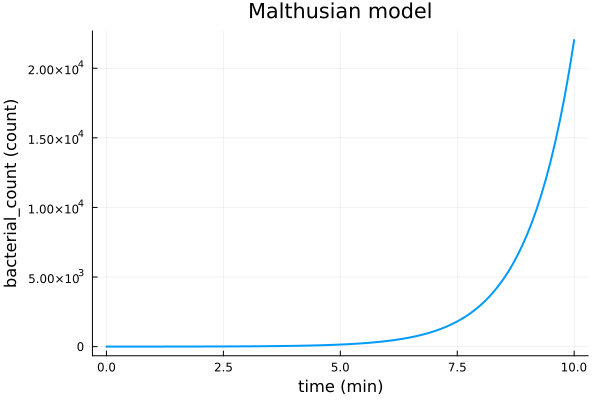

In [ ]:
using Plots
const r = 1 # 増加率のパラメータ
      n = 1 # 初期値（初期菌体数）

function f(t)
    return n * exp(r * t)
end

t = range(0, 10, length=100)
bacterial_count = f.(t)

# 5. 可視化
plot(t, bacterial_count,
     xlabel = "time (min)",
     ylabel = "bacterial_count (count)",
     title = "Malthusian model",
     legend = false,
     linewidth = 2)

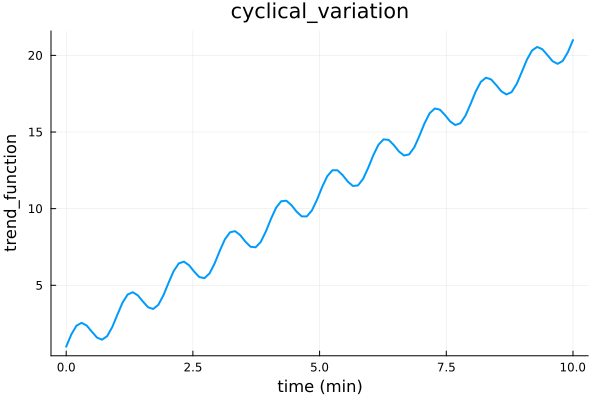

In [1]:
# トレンドモデル
using Plots
const a = 2
      b = 1
      w = 2
      w1 = 3
      w2 = 4

function f(x)
    return a * x + b + sin(pi * w * x)
end

x = range(0 , 10, length=100)
cyclical_variation = f.(x)

# 5. 可視化
plot(x, cyclical_variation,
     xlabel = "time (min)",
     ylabel = "trend_function",
     title = "cyclical_variation",
     legend = false,
     linewidth = 2)


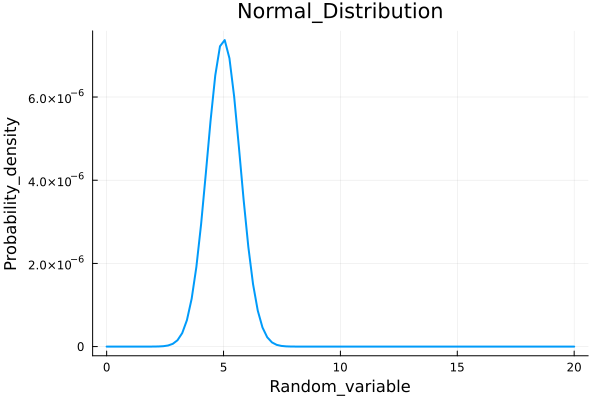

In [ ]:
# 正規分布(Normal_Distribution)の出力
using Plots
const a = 5
      s1 = 30
      b = sqrt(pi * 2)

function f(x)
    return exp(-1 * (x - a)^2) / (2 * s1^2) / (b * s1)
end

x = range(0 , 20, length=100)
normal_distribution = f.(x)

# 5. 可視化
plot(x, normal_distribution,
     xlabel = "Random_variable",
     ylabel = "Probability_density",
     title = "Normal_Distribution",
     legend = false,
     linewidth = 2)

# 感染症の累計感染拡散のモデル
- 接触人数 contact
- 感染力   infectivity (0<i<1)
- 感染者数 infected
## モデルの説明
1. 初期の感染者数×(１～１０)の式で接触人数を定義しさらに感染力(０～１)を掛けて次の感染者数とする。
2. 時間の進み方は１日単位で３０日行う


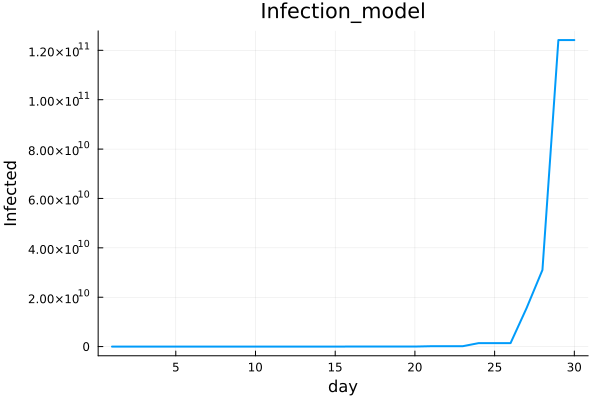

In [38]:
# 感染拡大・収束モデル
using Plots
using Random

# 各変数の定義
infected = 1    # 感染者数
infectivity = 1 # 感染力
contact = 1     # 接触人数
d = zeros(30)
sum = zeros(30)

function f(infected, contact, infectivity)
    infected = infected * contact * infectivity
    return infected
end

for t in eachindex(sum)
    contact = rand(1:10)
    infectivity = rand(0:1)
    buffer = infected
    d[t] = t
    infected = f(infected, contact, infectivity) + buffer
    sum[t] = infected
end

# 5. 可視化
plot(d, sum,
     xlabel = "day",
     ylabel = "Infected",
     title = "Infection_model",
     legend = false,
     linewidth = 2)

